In [1]:
import torch
import time
import imageio
import random
import numpy as np
import pandas as pd 
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch.nn.functional as F

In [2]:
def set_seed(seed):
	"""Set the random seed for reproducibility."""
	torch.manual_seed(seed)
	np.random.seed(seed)
	random.seed(seed)
	if torch.cuda.is_available(): 
		torch.cuda.manual_seed(seed)
set_seed(42) # For reproducibility

## ODE Solver

In [3]:
def euler_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim])
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0
	for i in range(1, len(t)): 
		dt = t[i] - t[i - 1] # time step
		y = y + func(t[i - 1], y) * dt # Euler step
		ys.append(y)

	return torch.stack(ys, dim=0)  # shape: [T, batch, dim]

In [4]:
def improved_euler_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim] 
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0 
	for i in range(1, len(t)):
		dt = t[i] - t[i - 1]
		k1 = func(t[i-1], y)
		k2 = y + k1 * dt
		y = y + (k1 + func(t[i], k2)) * dt / 2
		ys.append(y)
	return torch.stack(ys, dim=0)


In [5]:
def rk2_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim]
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0 
	for i in range(1, len(t)):
		dt = t[i] - t[i - 1]
		k1 = func(t[i-1], y)
		k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
		y = y + k2 * dt
		ys.append(y)
	return torch.stack(ys, dim=0)

In [6]:
def rk4_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim]
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0 
	for i in range(1, len(t)):
		dt = t[i] - t[i - 1]
		k1 = func(t[i-1], y)
		k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
		k3 = func(t[i-1] + dt/2, y + k2 * dt / 2)
		k4 = func(t[i-1] + dt, y + k3 * dt)
		y = y + (k1 + 2*k2 + 2*k3 + k4) * dt / 6
		ys.append(y)
	return torch.stack(ys, dim=0)

## Neural ODE

In [7]:
class ODEFunc(nn.Module):
	"""
    Defines the learned dynamics (f(t, y)) for the Neural ODE.
    This network approximates the derivative dC/dt of the 4-compartment system.
    """
	def __init__(self):
		# Define a shallow MLP to learn non-linear drug clearance rates
        # Input (4): Concentrations C1-C4 | Output (4): Respective rates of change
		super().__init__()
		self.net = nn.Sequential(nn.Linear(4, 20), # Hidden layer with 20 neurons
										nn.Tanh(),
										nn.Linear(20, 4)) # Output layer to return dC/dt
		for m in self.net.modules(): 
			if isinstance(m, nn.Linear): 
				# Normal distribution helps prevent vanishing/exploding gradients early on
				nn.init.normal_(m.weight, mean=0, std=0.1)
				# Biases set to zero to ensure no initial directional preference
				nn.init.constant_(m.bias, val=0)

	def forward(self, t, y):
		output = self.net(y)

		# Physics-Informed Damping:
        # Forces the system toward equilibrium (C=0) to prevent numerical 
        # instabilities and represent physical drug clearance.
		damping = -0.03 * y
		output = output + damping

		return output

## Data Processing

In [8]:
# Load simulation data
# If the code is run from models/NeuralODE/, use the following path:
data = pd.read_csv('../../FINAL_mrgsolve_simulation.csv')
# if the code is run from the root directory, use the following path:
#data = pd.read_csv('FINAL_mrgsolve_simulation.csv')

# Convert data to numpy arrays
t_np = data['time'].values.astype(np.float32)
C1_np = data['CENT'].values.astype(np.float32)
C2_np = data['PERIPH'].values.astype(np.float32)
C3_np = data['PERIPH2'].values.astype(np.float32)
C4_np = data['CP'].values.astype(np.float32)

# Verify shapes of the arrays
print(t_np.shape, C1_np.shape, C2_np.shape, C3_np.shape, C4_np.shape)

(481,) (481,) (481,) (481,) (481,)


In [9]:
def data_processing(t_np, c1, c2, c3, c4, ratio=0.8, split=True):
	"""
	Prepares time and concentration data for Neural ODE training.
	If split=True:
		- Splits dataset into train/test based on ratio 
		- Computes mu, sigma only from train data
		- Normalizes both train and test using train mean and std
	If split=False:
		- No splitting
		- Normalize entire dataset using global mu/sigma
	"""
	t = torch.tensor(t_np, dtype=torch.float32)
	C1 = torch.tensor(c1, dtype=torch.float32)
	C2 = torch.tensor(c2, dtype=torch.float32)
	C3 = torch.tensor(c3, dtype=torch.float32)
	C4 = torch.tensor(c4, dtype=torch.float32)
	print("Shapes:", C1.shape, C2.shape, C3.shape, C4.shape)

	# Stack individual compartments into a single multi-dimensional state tensor [T, 4]
	C_all = torch.stack([C1, C2, C3, C4], dim=1)

	# Add batch dimension -> [T, 1, 4] 
	C_all = C_all.unsqueeze(1)

	# No splitting 
	if not split:
		mu = C_all.mean(dim=0, keepdim=True) # shape [1,1,4]
		sigma = C_all.std(dim=0, keepdim=True) + 1e-8

		C_all_norm = (C_all - mu) / sigma

		train_C_norm = C_all_norm
		train_t = t
	else: 
		# Determine the split point based on the specified ratio
		data_size = C_all.shape[0]
		split_idx = int(data_size * ratio)

		# Slice the data into training and testing temporal sequences
		train_C = C_all[:split_idx] 
		train_t = t[:split_idx]
		test_C = C_all[split_idx:] 
		test_t = t[split_idx:]

		# Calculate Mean and Std ONLY from the training set 
        # This prevents data leakage from the future (test set) into the model.
		mu = train_C.mean(dim=0, keepdim=True)
		sigma = train_C.std(dim=0, keepdim=True) + 1e-8

		# Normalize train and test using Train mean and standard deviation
		train_C_norm = (train_C - mu) / sigma
		test_C_norm = (test_C - mu) / sigma

		# Combine normalized back for full C_all if needed
		C_all_norm = torch.cat([train_C_norm, test_C_norm], dim=0)

	# Return a dictionary of tensors and parameters for training loop use
	return {
		"t": t,
		"C_all": C_all_norm,
		"mu": mu,
		"sigma": sigma,
		"split_idx": split_idx if split else None,
		"train_C": train_C_norm,
		"train_t": train_t,
		"test_C": test_C_norm if split else None,
		"test_t": test_t if split else None
	}

In [10]:
def get_batch(C, t, batch_time, batch_size):
	"""
    Creates a random batch of short time-series segments for training.
    
    Args:
        C: Normalized concentration tensor [Total_Time, 1, 4]
        t: Time vector [Total_Time]
        batch_time: Number of consecutive time steps per segment
        batch_size: Number of random segments per training iteration
    """
	# Randomly pick starting indices 's' for the batches
    # We ensure (s + batch_time) does not exceed the total data length
	data_size = C.shape[0]
	s = torch.from_numpy(np.random.choice(np.arange(data_size - batch_time, dtype=np.int64), batch_size, replace=False))
	# Extract initial concentrations at the chosen starting points
	batch_c0 = C[s]  # (batch_size, 1, emb)
	# Create a relative time vector for the segment (starting from t=0)
	batch_t = t[:batch_time]  # (T)
	# Stack consecutive data points to create the target trajectories
	batch_c = torch.stack([C[s + i] for i in range(batch_time)], dim=0)  # (time, batch_size, 1, emb)
	return batch_c0, batch_t, batch_c

# Graph Generation

In [11]:
def visualize(data_dict, pred_all):
	"""
	Plots the ground truth data against Neural ODE predictions.
	Handles inverse normalization and highlights the train/test boundary.
	t torch.Size([97])
	C_all torch.Size([97, 1, 4])
	mu torch.Size([1, 1, 4])
	sigma torch.Size([1, 1, 4])
	split_idx 77
	train_C torch.Size([77, 1, 4])
	train_t torch.Size([77])
	test_C torch.Size([20, 1, 4])
	test_t torch.Size([20])
	"""
	# Data Extraction & Reshaping
    # Removing the batch dimension (1) for easier plotting: [Time, 1, 4] -> [Time, 4]
	t = data_dict["t"]
	C_all = data_dict["C_all"].squeeze(1)
	pred_all = pred_all.squeeze(1)

	# Extract normalization constants
	mu = data_dict["mu"].squeeze(0)
	sigma = data_dict["sigma"].squeeze(0)

	split_idx = data_dict.get("split_idx", None)
	test_t = data_dict.get("test_t", None)

	# Inverse Normalization (Standard Scaling Back to Original Units)
    # Physical Amount = (Normalized_Value * Sigma) + Mu
	ture_all_orig = C_all * sigma + mu
	pred_all_orig = pred_all * sigma + mu

	fig = plt.figure(figsize=(10,6), constrained_layout=True)
	colors = ['blue', 'orange', 'green', 'red']
	compartment = ['Central', 'Peripheral 1', 'Peripheral 2', 'CP']

	# Separate training segments for visual distinction
	if split_idx is not None:
		t_train = t[:split_idx]
		true_train = ture_all_orig[:split_idx]
		pred_train = pred_all_orig[:split_idx]
	else: 
		t_train = t
		true_train = ture_all_orig
		pred_train = pred_all_orig

	# Plotting Training Data
    # Scatter dots for experimental data; Solid lines for model predictions
	for i in range(4):
		plt.scatter(t_train, true_train[:,i], color=colors[i], marker='o', alpha=0.3, label=f'True {compartment[i]}', s=5)
		plt.plot(t_train, pred_train[:,i], linestyle='-', color=colors[i], label=f'Train Pred {compartment[i]}')

	# Plotting Validation/Test Data
    # Uses dashed lines (--) to indicate the model is forecasting unseen data
	if split_idx is not None and test_t is not None:
		t_test = t[split_idx:]
		true_test = ture_all_orig[split_idx:]
		pred_test = pred_all_orig[split_idx:]
		for i in range(4):
			plt.scatter(test_t, true_test[:,i], color=colors[i], marker='o', s=5)
			plt.plot(t_test, pred_test[:,i], linestyle='--', color=colors[i], label=f'Test Pred {compartment[i]}')
		# Vertical line to clearly show where training ended and validation began
		plt.axvline(t[split_idx], color='gray', linestyle=':', linewidth=2, label="Train/Test Split")

	plt.xlabel('Time (hr)')
	plt.ylabel('Amount (mg)')
	plt.title(f'True vs Predicted Amounts')
	plt.legend(bbox_to_anchor=(0.5, 1), loc='upper left') 
	plt.grid(True)
	plt.show()
	return fig

In [12]:
def plot_loss(train_loss, test_loss=None, niters=400, log_every=20):
	"""
    Visualizes the optimization progress by plotting loss curves.
    
    Args:
        train_loss: List of training loss values recorded during optimization.
        test_loss: Optional list of validation/test loss values.
        niters: Total number of iterations the model was trained for.
        log_every: The frequency at which loss was recorded (step size for x-axis).
    """
	plt.figure(figsize=(10, 6))
	# Generate the x-axis points based on the logging frequency
    # This aligns the loss values with their actual iteration number
	x_axis = np.arange(0, niters+1, log_every)
	
	# Plot the Training Loss (Measures how well the model fits the 80% data)
	plt.plot(x_axis, train_loss, '-', markersize=3, label="Train Loss")

	# If provided, plot the Test Loss (Measures generalization on the 20% data)
	if test_loss is not None and len(test_loss) > 0:
		plt.plot(x_axis, test_loss, label="Test Loss")
	plt.xlabel("Iteration")
	plt.ylabel("Loss")
	plt.title("Training and Test Loss Over Iterations")
	plt.legend()
	plt.grid(True)
	plt.show()

# ODE Training

In [13]:
def train_NODE(data_dict, solver, niters=400, lr=1e-3, batch_size=1, gif=False):
	"""
    Main training pipeline for the Neural ODE.
    
    Args:
        data_dict: Dictionary containing processed tensors (t, C_all, train/test splits).
        solver: The ODE integration function (e.g., odeint from torchdiffeq).
        niters: Number of optimization epochs.
        lr: Learning rate for the Adam optimizer.
        batch_size: Number of random trajectories sampled per iteration.
        gif: Boolean to toggle saving an animation of the learning process.
    """
	func = ODEFunc()
	# Adam optimizer with L2 Regularization (weight_decay) to prevent overfitting
	optimizer = optim.Adam(func.parameters(), lr=lr, weight_decay = 1e-4)
	train_loss_history = []
	test_loss_history = []
	criterion = nn.MSELoss() # Base loss function (Mean Squared Error)

	# Only create frame storage if gif=True
	frames = [] if gif else None

	start_time = time.time()

	# Extract data from dictionary
	t = data_dict["t"]
	C_all = data_dict["C_all"]

	train_C = data_dict["train_C"]
	train_t = data_dict["train_t"]
	test_C  = data_dict.get("test_C", None)
	test_t  = data_dict.get("test_t", None)

	# Initial condition C(0) for the training sequence
	C_0 = train_C[0, 0, :].unsqueeze(0)
	train_size = train_C.shape[0]
	batch_time = train_size - 1

	# --- main training loop ---
	for iter in range(niters + 1):
		optimizer.zero_grad()
		# Get random sub-segments of the trajectory to make training more robust
		batch_c0, batch_t, batch_c = get_batch(train_C, train_t, batch_time, batch_size)

		# Forward pass: Solve dC/dt = func(C, t) over the batch time window
		pred_C = solver(func, batch_c0, batch_t)

		# Batch loss
		loss = torch.sqrt(criterion(pred_C, batch_c)) # Compute using RMSE loss 
		# loss = criterion(pred_C, batch_c) # Compute using MSE loss 
		loss.backward() # Compute gradients through the ODE solver (Adjoint method or Backprop)
		optimizer.step() 
		# Logging and Validation (Every 20 iterations)
		if iter % 20 == 0 or iter == niters:
			with torch.no_grad():
				# Predict full training trajectory
				pred_train = solver(func, C_0, train_t)

				train_loss = torch.sqrt(criterion(pred_train, train_C)) # Compute using RMSE loss 
				# train_loss = criterion(pred_train, train_C) # Compute using MSE loss 

				train_loss_history.append(train_loss.item())
				# Test Evaluation: Forecast into the future using the last training state
				if test_C is not None:
					test_start_state = pred_train[-1] 
					pred_test = solver(func, test_start_state, test_t)

					test_loss = torch.sqrt(criterion(pred_test, test_C))  # Compute using RMSE loss 
					# test_loss = criterion(pred_test, test_C) # Compute using MSE loss 
					test_loss_history.append(test_loss.item()) 
				else:
					test_loss = None
				print(f"Iter {iter:04d} | Total Loss {train_loss.item():.6f} | Test Loss: {test_loss.item():.6f}" if test_loss is not None else 'N/A')
	
		# Real-time Visualization (Every 50 iterations)
		if iter % 50 == 0:
			with torch.no_grad():
				clear_output(wait=True) # Refresh the notebook output
				# Only save frames if gif=True
				# always show visualization
				pred_all = solver(func, C_0, t)
				fig = visualize(data_dict, pred_all)
				# Optional GIF Frame Capture
				if gif:
					fig.canvas.draw()
					buf = fig.canvas.buffer_rgba()
					image = np.asarray(buf, dtype=np.uint8)
					frames.append(image)
				plt.close(fig)
	print(f"Final Train Loss {train_loss_history[-1]:.6f} | Test Loss: {test_loss_history[-1]:.6f}" if test_loss is not None else 'N/A')
	
	with torch.no_grad():
		pred_all_C = solver(func, C_0, t)
		pred_train_C = pred_all_C[:len(train_t)]
		pred_test_C = pred_all_C[len(train_t):] if test_C is not None else None

	# Plot the loss curves to check for convergence or overfitting
	plot_loss(train_loss_history, test_loss_history, niters, 20)

	# Save GIF only when user requests it
	if gif:
		imageio.mimsave(f"training_animation_{solver}.gif", frames, fps=2)
		print("Saved GIF: training_animation.gif")

	print(f"Process time: {time.time() - start_time:.2f} sec")
	return pred_train_C, pred_test_C, func

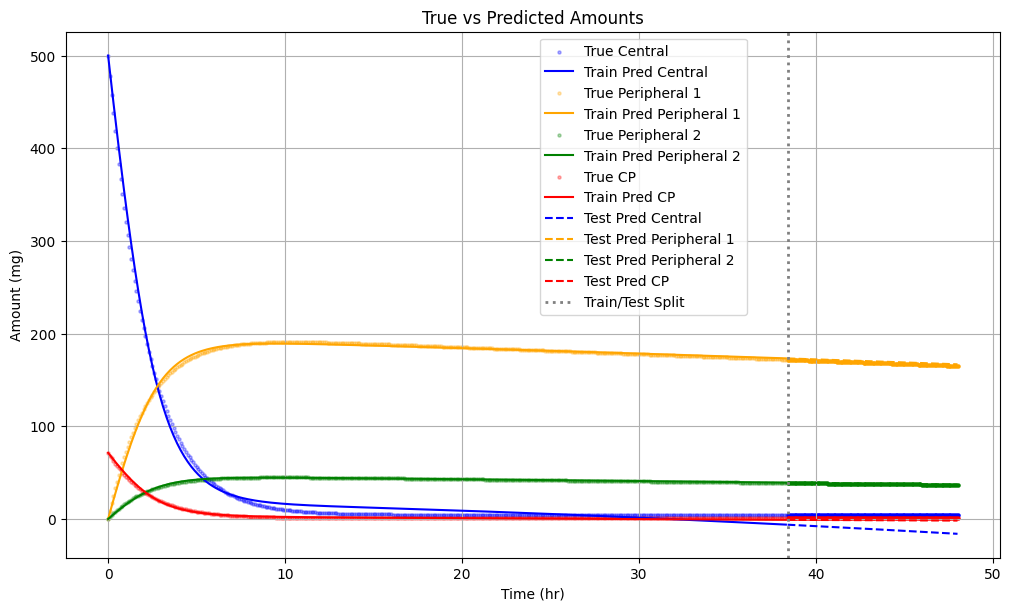

Final Train Loss 0.071150 | Test Loss: 0.130291


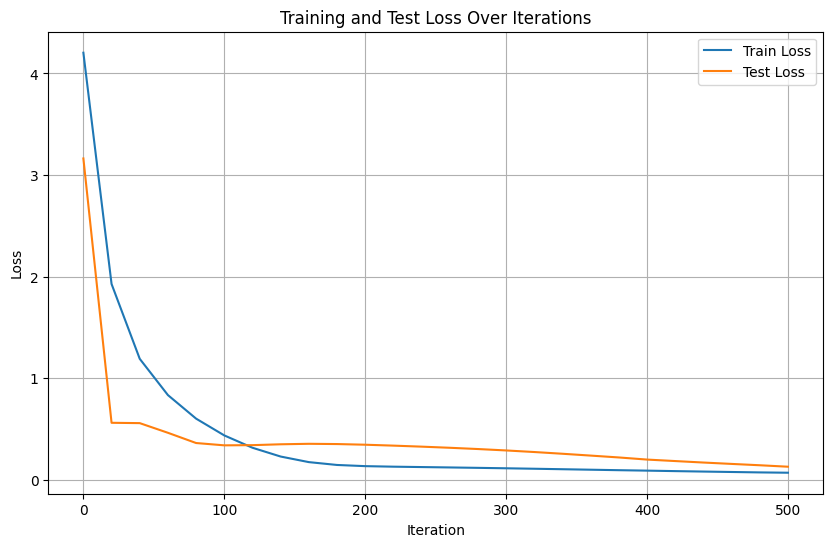

Saved GIF: training_animation.gif
Process time: 27.66 sec


In [14]:
# Solve using Euler method 
data_dict = data_processing(t_np, C1_np, C2_np, C3_np, C4_np, ratio=0.8, split=True)
pred_train_C, pred_test_C, func = train_NODE(data_dict, improved_euler_solver, niters = 500, lr=1e-3, batch_size=1, gif=True)

In [15]:
# # Solve using Euler method
# pred_train_C, pred_test_C, func = train_NODE(data_dict, euler_solver, niters = 500, lr=5e-4, batch_size=1, method='dopri5', gif=True)

In [16]:
# # Solve using runge-Kutta 4th order method
# pred_train_C, pred_test_C, func = train_NODE(data_dict, rk4_solver, niters = 800, lr=5e-4, batch_size=1, method='dopri5', gif=True)

In [17]:
print(pred_train_C.shape)
print(data_dict['train_C'].shape)

torch.Size([384, 1, 4])
torch.Size([384, 1, 4])


## Evaluation

Residual 

In [18]:
def plot_residual(t, train_C, test_C, final_train_pred, final_test_pred = None, split_idx = None):
	"""
    Computes and visualizes the prediction errors (residuals) over time.
    Residual = (Experimental Data - Model Prediction).
    
    Args:
        t: Time vector [Total_Time]
        train_C, test_C: Original (unnormalized) ground truth concentration tensors.
        final_train_pred, final_test_pred: Final model predictions in original units.
        split_idx: The index marking the end of the training data.
    """
	# Removing batch dimension to allow plotting: [Time, 1, 4] -> [Time, 4]
	train_residual = ((train_C - final_train_pred)).squeeze(1)
	test_residual = ((test_C - final_test_pred)).squeeze(1) if test_C is not None else None
	colors = ['blue', 'orange', 'green', 'red']
	plt.figure(figsize=(10,6))
	# Handle split_idx if not explicitly provided
	if split_idx is None:
			split_idx = len(train_residual) 
			print(len(train_residual))
	
	for i in range(4):
		# Training residuals: should ideally be randomly scattered around zero
		plt.scatter(t[:split_idx], train_residual[:, i], color=colors[i], alpha = 0.5, s=6, label=f"Train Residual {i+1}")
		# Test residuals: indicate if the error increases as we forecast further out
		if test_residual is not None:
			plt.scatter(t[split_idx:], test_residual[:, i], color=colors[i], marker='+', s=8,label=f"Test Residual {i+1}")
	if test_residual is not None:
			# Vertical line indicating where the model stops learning and starts forecasting
			plt.axvline(t[split_idx], color='gray', linestyle=':', linewidth=2, label="Train/Test Split")
	print("Max Train Residual:", train_residual.max(), "Max Test Residual:", test_residual.max() if test_residual is not None else "N/A")
	plt.xlabel("Time")
	plt.ylabel("Residual (True - Pred) (mg)")
	plt.title("Unnormalized Residual vs Time (Train + Test)")
	plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
	plt.grid(True)
	plt.show()

Max Train Residual: tensor(0.2648) Max Test Residual: tensor(0.2451)


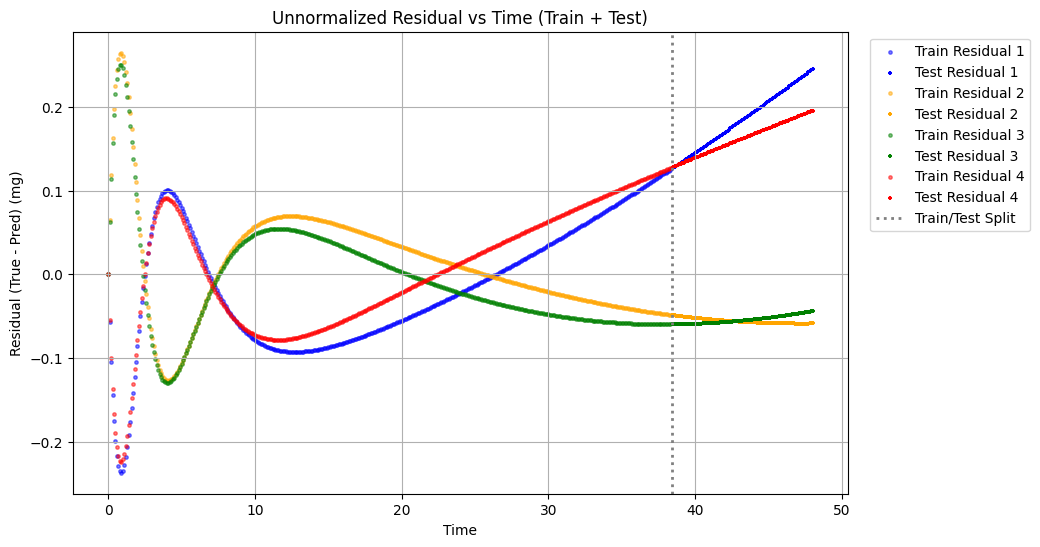

In [19]:
plot_residual(data_dict['t'], data_dict['train_C'], data_dict['test_C'], pred_train_C, pred_test_C, split_idx = data_dict['split_idx'])

Sensitivity to Initial Conditions

In [20]:
def init_sensitivity(data_dict, solver, func):
	"""
    Performs Global Sensitivity Analysis to quantify how perturbations in 
    initial concentrations (C0) affect the entire drug trajectory.
    """
	func.eval()
	eps = 1e-3 # Small constant to prevent division by zero during relative scaling
	
	# Prepare Initial Condition
	C0 = data_dict['train_C'][0, 0, :].clone().detach().requires_grad_(True)
	t = data_dict['t']

	# Compute Jacobian of the solver w.r.t C0
	
	def get_traj(c_init):
		return solver(func, c_init.unsqueeze(0), t).squeeze(1)
	# This calculates d(Trajectory)/d(C0). 
    # Resulting shape: [Time, Output_Dim, Input_Dim]
	jac = torch.autograd.functional.jacobian(get_traj, C0) 

	# Calculate Relative Sensitivity (Dimensionless)
	with torch.no_grad():
		pred = get_traj(C0)
		# Relative Sens = (dC_out / dC_in) * (C_in / C_out)
		# Use broadcasting: jac is [T, D_out, D_in], C0 is [D_in], pred is [T, D_out]
		rel_sens = jac * (C0.view(1, 1, -1) / (pred.unsqueeze(-1) + eps))

	# We take the mean absolute sensitivity across all time points to see the overall impact
	global_map = rel_sens.abs().mean(dim=0).detach().cpu().numpy()
	
	# Heatmap Visualization
	plt.figure(figsize=(8, 6))
	sns.heatmap(global_map, annot=True, fmt=".2f", cmap="YlGnBu",
				xticklabels=[f"C{i+1}(0)" for i in range(C0.shape[0])],
				yticklabels=[f"C{i+1}(t)" for i in range(C0.shape[0])])
	
	plt.title("Influence of Initial Conditions (Relative %)")
	plt.xlabel("Input: Initial State")
	plt.ylabel("Output: Trajectory Component")
	plt.show()

	return rel_sens

Sensitivity to Neural ODE Parameters

In [21]:
def param_sensitivity(data_dict, solver, func):
	"""
    Analyzes how small changes in the Neural ODE's learned weights 
    impact the final predicted concentration state (C_final).
    """
	func.eval()
	train_C = data_dict['train_C']
	t = data_dict['t']
	# Define the initial condition C(0)
	C_0 = train_C[0, 0, :].unsqueeze(0)
	for name, p in func.named_parameters():
		  print(name, p.shape)
	
	# We solve the ODE for the entire trajectory and look at the final time point [-1]
	last_pred_C = solver(func, C_0, t)[-1]

	# Backpropagate to find Parameter Gradients
	# last_pred_C.sum() allows us to get the gradient of the entire state vector 
    # with respect to every weight in the network simultaneously.
	sensitivity = torch.autograd.grad(last_pred_C.sum(), func.parameters(), create_graph=True)

	# Normalized Relative Sensitivity Calculation
	eps = 1e-6 # Prevents division by zero
	for (name, p), grad in zip(func.named_parameters(), sensitivity):
		rel_sens = (grad * p / (last_pred_C.abs().mean() + eps)).detach()
		# Only plot 2D layers (Weights), as 1D layers (Biases) are less informative for heatmaps
		if rel_sens.ndim == 2: 
			plt.figure(figsize=(8,6))
			sns.heatmap(rel_sens.detach().abs().cpu(), cmap="viridis")
			plt.title(f"Sensitivity heatmap: {name}")
			plt.xlabel("Input")
			plt.ylabel("Hidden unit")
			plt.show() 

In [ ]:
init_sen = init_sensitivity(data_dict, improved_euler_solver, func)
param_sensitivity(data_dict, improved_euler_solver, func)

Stability Analysis

In [ ]:
def check_linear_stability(func, current_state, t=0):
	"""
    Evaluates the local stability of the Neural ODE at a specific state 'C'.
    It linearizes the system using the Jacobian matrix and checks if all
    eigenvalues have negative real parts.
    """
	func.eval()
	# Ensure the state 'C' can track gradients to compute the Jacobian
	C = current_state.clone().detach().requires_grad_(True)
	# Define the function for the Jacobian (f(C, t))
	def ode_rhs(c_input):
		return func(t, c_input)
	
	# Compute Jacobian [Dim, Dim]
	# J_ij = df_i / dC_j. This matrix represents the linear best-fit 
    # of the system's dynamics at the current concentration point.
	jac = torch.autograd.functional.jacobian(ode_rhs, C).squeeze()

	# Compute Eigenvalues
	eigenvalues = torch.linalg.eigvals(jac.detach().cpu())
	real_parts = eigenvalues.real

	# Interpret Results
	# A system is Locally Asymptotically Stable if ALL real parts < 0.
    # If any real part > 0, the system is Unstable (errors will grow).
	is_stable = torch.all(real_parts < 0)
	
	print(f"Eigenvalues: {eigenvalues}")
	print(f"Max Real Part: {torch.max(real_parts):.4f}")
	print(f"System is {'STABLE' if is_stable else 'UNSTABLE'} at this point.")
	
	return eigenvalues

In [ ]:
# --- STABILITY TRAJECTORY ANALYSIS ---

# Analyze the Training Phase (First 38.4 hours / 384 time steps)
# This loop checks if the Neural ODE learned a stable vector field 
# for the data it was actually trained on.
for i in range(384):
    currentstate = pred_train_C[i]
    # Evaluate the Jacobian and Eigenvalues at the specific concentration 'currentstate'
    check_linear_stability(func, currentstate)

# Analyze the Testing/Forecasting Phase (Last 9.6 hours / 97 time steps)
# This is the "Stress Test." It checks if the system remains stable 
# when extrapolating into unseen future time points.
for i in range(97):
    currentstate = pred_test_C[i]
    # Monitoring for "Bifurcation": Looking for the moment an eigenvalue's 
    # real part crosses from negative to positive.
    check_linear_stability(func, currentstate)

Eigenvalues: tensor([-0.1136+0.0000j, -0.0251+0.0202j, -0.0251-0.0202j, -0.0249+0.0000j])
Max Real Part: -0.0249
System is STABLE at this point.
Eigenvalues: tensor([-0.1224+0.0000j, -0.0246+0.0209j, -0.0246-0.0209j, -0.0243+0.0000j])
Max Real Part: -0.0243
System is STABLE at this point.
Eigenvalues: tensor([-0.1320+0.0000j, -0.0241+0.0217j, -0.0241-0.0217j, -0.0236+0.0000j])
Max Real Part: -0.0236
System is STABLE at this point.
Eigenvalues: tensor([-0.1425+0.0000j, -0.0235+0.0225j, -0.0235-0.0225j, -0.0228+0.0000j])
Max Real Part: -0.0228
System is STABLE at this point.
Eigenvalues: tensor([-0.1538+0.0000j, -0.0228+0.0233j, -0.0228-0.0233j, -0.0220+0.0000j])
Max Real Part: -0.0220
System is STABLE at this point.
Eigenvalues: tensor([-0.1659+0.0000j, -0.0221+0.0240j, -0.0221-0.0240j, -0.0211+0.0000j])
Max Real Part: -0.0211
System is STABLE at this point.
Eigenvalues: tensor([-0.1790+0.0000j, -0.0213+0.0248j, -0.0213-0.0248j, -0.0201+0.0000j])
Max Real Part: -0.0201
System is STABLE 